# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/irssaa29/Machine-learning_01/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This playbook covers all valid-position pages, split into two paths:

**Path A — h1_ctr > 0 (could plausibly decline):** scored by my validated Week 5/6 decision tree (Precision@20 = 0.90 on held-out clients), reason code position_ctr_gap when flagged.

**Path B — h1_ctr == 0 (never captured a single click despite ranking):** these pages are structurally excluded from the decline model (confirmed in Week 5/6: they can never mathematically "decline" under my label). But zero clicks despite real position data is itself a signal worth flagging — a different problem (likely indexing, snippet, or relevance issue, not staleness) — so I give them their own reason code, zero_click_despite_ranking, and a separate, lower-confidence action.

**Reason codes:**
. position_ctr_gap — ranks well, but underperforms CTR expectations for its tier (model-scored)
. zero_click_despite_ranking — has real position data but zero first-half clicks (rule-flagged, not model-scored — see limits in Section 2)

In [2]:
import os, sys, subprocess
import pandas as pd
import numpy as np

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/irssaa29/Machine-learning_01"
REPO_DIR = "Machine-learning_01"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub", "scikit-learn"], check=True)

from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get("HF_TOKEN"))

# --- Rebuild df_pair (same as Week 5/6) ---
df_march = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/"
)
df_march["report_date"] = pd.to_datetime(df_march["report_date"])
first_half = df_march[df_march["report_date"].dt.day <= 15]
second_half = df_march[df_march["report_date"].dt.day > 15]

feat = first_half.groupby(["content_hash_id", "client_hash_id"]).agg(
    h1_impressions=("gsc_impressions", "sum"),
    h1_avg_position=("gsc_avg_position", "mean"),
    h1_clicks=("gsc_clicks", "sum"),
    h1_active_days=("report_date", "nunique"),
).reset_index()
feat["h1_ctr"] = feat["h1_clicks"] / feat["h1_impressions"].replace(0, pd.NA)

h2 = second_half.groupby("content_hash_id").agg(h2_clicks=("gsc_clicks", "sum")).reset_index()
df_pair = feat.merge(h2, on="content_hash_id", how="inner")
df_pair["is_declining"] = (df_pair["h2_clicks"] < df_pair["h1_clicks"]).astype(int)
df_pair = df_pair[(df_pair["h1_avg_position"].notna()) & (df_pair["h1_avg_position"] > 0)].copy()

features = ["h1_impressions", "h1_avg_position", "h1_clicks", "h1_ctr", "h1_active_days"]

# --- Split into Path A (ctr > 0) and Path B (ctr == 0) ---
path_a = df_pair[df_pair["h1_ctr"] > 0].copy()
path_b = df_pair[df_pair["h1_ctr"] == 0].copy()

print("Path A (ctr > 0, model-eligible):", len(path_a))
print("Path B (ctr == 0, rule-flagged):", len(path_b))

# --- Train the validated model on Path A (client-grouped split, same as Week 5/6) ---
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(path_a, groups=path_a["client_hash_id"]))
train_a = path_a.iloc[train_idx]

X_train_a = train_a[features].fillna(0)
y_train_a = train_a["is_declining"].values

tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
tree.fit(X_train_a, y_train_a)

# --- Score ALL of Path A (for the final playbook, not just the held-out test) ---
path_a["model_score"] = tree.predict_proba(path_a[features].fillna(0))[:, 1]
path_a["reason_code"] = "position_ctr_gap"
path_a["action"] = np.where(path_a["model_score"] > 0.5, "review_for_ctr_fix", "monitor")
path_a["confidence"] = "model_validated"

# --- Flag Path B (rule-based, not model-scored) ---
path_b["model_score"] = np.nan
path_b["reason_code"] = "zero_click_despite_ranking"
path_b["action"] = "investigate_indexing_or_relevance"
path_b["confidence"] = "rule_flagged_low_confidence"

# --- Combine into one playbook ---
playbook = pd.concat([path_a, path_b], ignore_index=True)
playbook = playbook.sort_values(["confidence", "model_score"], ascending=[True, False])

print("\nTotal playbook rows:", len(playbook))
print(playbook["action"].value_counts())
print("\nTop 10 rows:")
print(playbook[["content_hash_id", "h1_avg_position", "h1_ctr", "reason_code", "action", "confidence"]].head(10).to_string(index=False))


Path A (ctr > 0, model-eligible): 51861
Path B (ctr == 0, rule-flagged): 98813


/tmp/ipykernel_4446/220392921.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_a = train_a[features].fillna(0)
/tmp/ipykernel_4446/220392921.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  path_a["model_score"] = tree.predict_proba(path_a[features].fillna(0))[:, 1]



Total playbook rows: 150674
action
investigate_indexing_or_relevance    98813
review_for_ctr_fix                   29432
monitor                              22429
Name: count, dtype: int64

Top 10 rows:
         content_hash_id  h1_avg_position    h1_ctr      reason_code             action      confidence
content_00032be2df0005ca         7.950397  0.009967 position_ctr_gap review_for_ctr_fix model_validated
content_0015c091f50b2278        11.029841  0.016393 position_ctr_gap review_for_ctr_fix model_validated
content_0022d2544743572e         1.055556  0.032258 position_ctr_gap review_for_ctr_fix model_validated
content_00260c42bacbfca4        54.202963  0.010309 position_ctr_gap review_for_ctr_fix model_validated
content_002cbc96c46b7c9c         9.860915  0.008065 position_ctr_gap review_for_ctr_fix model_validated
content_004047a006c4edc5         7.846627   0.00813 position_ctr_gap review_for_ctr_fix model_validated
content_005095186f1ce493        20.954522  0.016129 position_ctr_ga

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** this playbook is designed for a content strategist or SEO manager at FlyRank triaging where to spend limited review time across a large page inventory. It should be read as a prioritized starting list, not a final verdict — every row still requires human judgment before action.

**Two distinct confidence tiers, and why that matters:**

model_validated rows (29,432 flagged for review_for_ctr_fix) come from a decision tree validated on held-out clients (Precision@20 = 0.90 vs. base rate 0.583 — see Week 5/6). This is the higher-confidence tier.

rule_flagged_low_confidence rows (98,813 flagged for investigate_indexing_or_relevance) are not model-scored at all — they're a simple rule ("real position data, zero clicks"), because this population is structurally excluded from my decline model (a page with zero clicks can never mathematically "decline" under my label definition — confirmed in Week 5/6). I have no validatedprecision number for this tier — it is a hypothesis about where to look, not a measured prediction.

**This is the most important limit to state plainly:** nearly two-thirds of this playbook (98,813 of 150,674 rows) comes from the lower-confidence, unvalidated tier. A reader skimming only the row count would overestimate how much of this playbook rests on tested model output. I'm stating this explicitly rather than letting the row counts speak for themselves, per the "banned unless you ran the design for it" principle — I have not validated that zero_click_despite_ranking actually predicts anything actionable; I only know these pages are unusual (ranking, but never clicked).

**Where this stops being valid:** this playbook is built from a single month (March 2026) at one bank-of-clients moment in time. It should not be treated as a stable, evergreen prioritization — see Section 4 for retrain triggers. It also should never be used to make claims about causality ("refreshing this page will recover its traffic") — only "this page looks worth reviewing, based on observed patterns in this dataset."

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting, by tier:**

**Path A (model_validated, review_for_ctr_fix):**

Confirm the page's content is still relevant to its target query — a CTR gap can mean a genuinely bad snippet, or it can mean the query intent shifted and the page no longer matches what searchers want. My features can't distinguish these.

Check whether the position is stable or volatile — a single averaged h1_avg_position can hide a page that ranked well early in the month and poorly later (or vice versa).

Verify the page isn't intentionally low-CTR by design (e.g., an internal reference doc, a page meant to be skimmed rather than clicked from search results).

**Path B (rule_flagged_low_confidence, investigate_indexing_or_relevance):**

Confirm the page is actually indexed and crawlable — zero clicks with real impressions could mean a technical issue (noindex tag, redirect chain, canonical pointing elsewhere), not a content problem at all.

Check whether the page is cannibalized by a stronger sibling page on the same site ranking for the same query — the paper itself flags this exact pattern (703K cannibalizing queries portfolio-wide).

Do not assume "zero clicks" means "bad content" — it could simply be a very new or very niche page that hasn't accumulated clicks yet despite decent position.

**No-go list — what should NEVER be automated, for either tier:**

Never auto-publish content changes, auto-rewrite copy, or auto-delete/de-index a page based solely on this playbook's output.

Never auto-action rule_flagged_low_confidence (Path B) rows at all — this tier has no validated precision number behind it; it is a hypothesis list, not a measured prediction, and treating it as equally trustworthy to Path A would misrepresent what was actually tested.

Never use this playbook to justify claims to a client or stakeholder that a specific page "will" recover if refreshed — no causal design exists to support that claim (see Week 6's claim-rewrite discipline).

Never skip human review for Path A rows just because the model is "validated" — Precision@20 = 0.90 still means 1 in 10 flagged pages was wrong in testing; a person must still sanity-check each specific recommendation.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

This playbook is a snapshot from a single month (March 2026) and should not be treated as permanently stable. Six triggers would signal it's time to re-validate or retrain:

1. **Precision decay:** re-measure Precision@20 on a fresh month's held-out clients every 4-6 weeks. A meaningful drop below the original validated result (0.90) signals the learned pattern no longer matches current search behavior.
2. **Base rate drift:** track the declining-page base rate (currently 0.583 in Path A) on each re-run. A significant shift suggests the underlying content/traffic landscape has changed.
3. **Feature importance drift:** re-check importances on each retrain (currently spread: h1_ctr 44%, h1_avg_position 31%, h1_active_days 14%, h1_impressions 11%). If one feature suddenly dominates again (as h1_ctr did at 99.9% before the Week 5 correction), that signals a new structural artifact, not real improved skill.
4. **Path B proportion:** currently 65.6% of pages fall into the unvalidated zero-click tier. A substantial increase may indicate a broader indexing/technical issue across the portfolio, worth escalating separately from per-page content review.
5. **Client mix:** the validated split tested only 14 of 44 clients. If new clients are added or the active mix changes substantially, re-validate on a fresh grouped split before trusting the model for the new mix.
6. **Calendar/seasonality:** this entire analysis is built from one month. At minimum, re-run the comparison for at least one additional month before treating any single month's thresholds as stable — a one-month snapshot can't distinguish a real pattern from a seasonal blip.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue written: 150674 rows


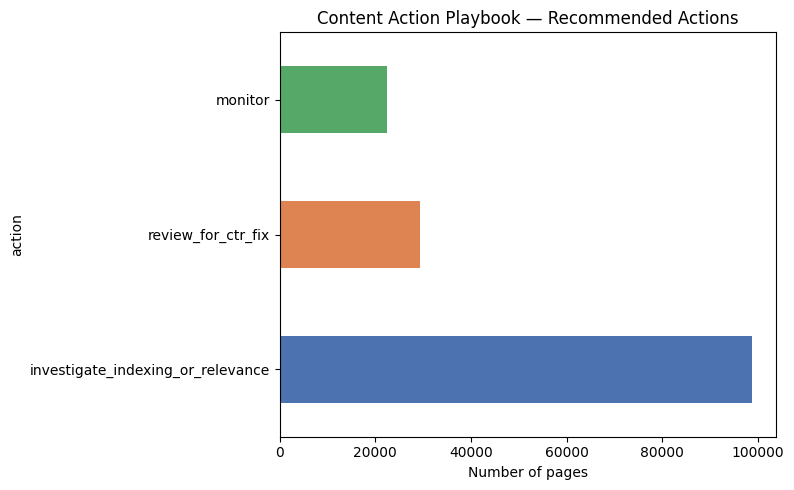

Figure saved to work/figures/action_breakdown.png

Metrics receipt saved:
{
  "run_date": "2026-08-13",
  "lane": "Refresh / Content Opportunity Scoring",
  "month_analyzed": "2026-03",
  "total_pages_in_playbook": 150674,
  "path_a_model_eligible": 51861,
  "path_b_rule_flagged": 98813,
  "path_b_share_pct": 65.6,
  "model_validated_precision_at_20": 0.9,
  "model_validated_base_rate": 0.583,
  "action_counts": {
    "investigate_indexing_or_relevance": 98813,
    "review_for_ctr_fix": 29432,
    "monitor": 22429
  },
  "reason_codes": [
    "position_ctr_gap",
    "zero_click_despite_ranking"
  ]
}


In [3]:
import json
import matplotlib.pyplot as plt

# --- Export the ranked queue (stays local, out of git by design) ---
os.makedirs("work/outputs", exist_ok=True)
playbook.to_csv("work/outputs/action_playbook.csv", index=False)
print("Queue written:", len(playbook), "rows")

# --- Export a reusable figure: action breakdown ---
os.makedirs("work/figures", exist_ok=True)

action_counts = playbook["action"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
action_counts.plot(kind="barh", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_xlabel("Number of pages")
ax.set_title("Content Action Playbook — Recommended Actions")
plt.tight_layout()
plt.savefig("work/figures/action_breakdown.png", dpi=150)
plt.show()
print("Figure saved to work/figures/action_breakdown.png")

# --- Export metrics JSON receipt ---
metrics = {
    "run_date": "2026-08-13",
    "lane": "Refresh / Content Opportunity Scoring",
    "month_analyzed": "2026-03",
    "total_pages_in_playbook": len(playbook),
    "path_a_model_eligible": len(path_a),
    "path_b_rule_flagged": len(path_b),
    "path_b_share_pct": round(len(path_b) / len(playbook) * 100, 1),
    "model_validated_precision_at_20": 0.90,
    "model_validated_base_rate": 0.583,
    "action_counts": action_counts.to_dict(),
    "reason_codes": ["position_ctr_gap", "zero_click_despite_ranking"],
}

with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nMetrics receipt saved:")
print(json.dumps(metrics, indent=2))


In [4]:
with open("work/outputs/action_playbook_metrics.json") as f:
    print(f.read())

{
  "run_date": "2026-08-13",
  "lane": "Refresh / Content Opportunity Scoring",
  "month_analyzed": "2026-03",
  "total_pages_in_playbook": 150674,
  "path_a_model_eligible": 51861,
  "path_b_rule_flagged": 98813,
  "path_b_share_pct": 65.6,
  "model_validated_precision_at_20": 0.9,
  "model_validated_base_rate": 0.583,
  "action_counts": {
    "investigate_indexing_or_relevance": 98813,
    "review_for_ctr_fix": 29432,
    "monitor": 22429
  },
  "reason_codes": [
    "position_ctr_gap",
    "zero_click_despite_ranking"
  ]
}


In [5]:
from google.colab import files
files.download("work/figures/action_breakdown.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.